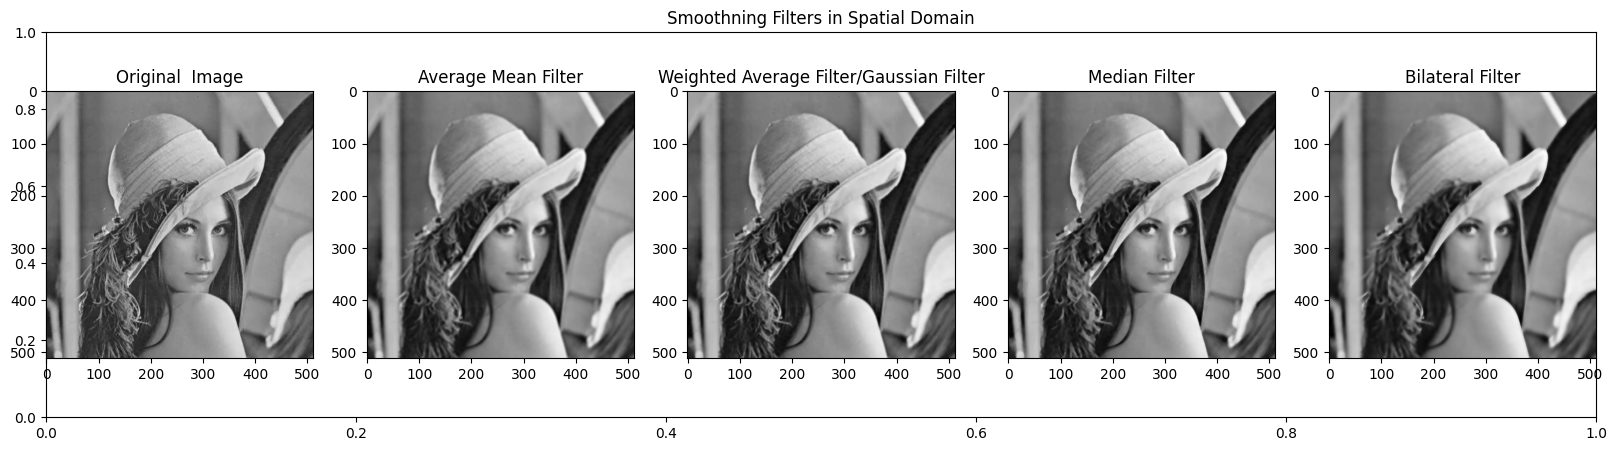

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
# Load an image (make sure 'sample.jpg' exists in the same directory)
# Use 0 for grayscale image, or 1 for color
img = cv2.imread('/content/LADY1.webp', 0)
import matplotlib.pyplot as plt
if img is None:
    print("Error: Image not found. Check the file path.")
else:
    # Define the kernel size (e.g., 5x5)
    # The kernel is a matrix of ones, divided by the total number of pixels in the kernel (5*5=25)
    kernel = np.ones((5, 5), np.float32) / 25

    # Apply the 2D convolution (filter2D)
    # -1 indicates that the output image will have the same depth as the input
    smoothed_img = cv2.filter2D(img, -1, kernel)

    # Alternatively, use the built-in cv2.blur function
    # smoothed_img = cv2.blur(img, (5, 5))

    # (5, 5) is kernel size, 0 is standard deviation (sigma) calculated from kernel size
    gaussian_blur = cv2.GaussianBlur(img, (5, 5), 0)
    #Median Filter
    #5 is the aperture linear size (must be an odd integer)
    median_blur = cv2.medianBlur(img, 5)
    # Display the original and smoothed images
    #Non linear filter
    bilateral_filter = cv2.bilateralFilter(img, 9, 75, 75)


# OpenCV uses BGR, Matplotlib uses RGB; convert before displaying
    #plt.imshow(cv2.cvtColor(smoothed_img , cv2.COLOR_BGR2RGB))
    #plt.axis('off')
    #plt.show()

plt.figure(figsize=(20, 5))
plt.title('Smoothning Filters in Spatial Domain')
plt.subplot(1, 5, 1),
plt.imshow(img,cmap='gray'),
plt.title('Original  Image')
plt.subplot(1, 5, 2), plt.imshow(smoothed_img,cmap='gray'),
plt.title('Average Mean Filter')
plt.subplot(1, 5, 3), plt.imshow(gaussian_blur,cmap='gray'),
plt.title('Weighted Average Filter/Gaussian Filter')
plt.subplot(1, 5, 4), plt.imshow(median_blur,cmap='gray'),
plt.title('Median Filter')
plt.subplot(1, 5, 5), plt.imshow(bilateral_filter,cmap='gray'),
plt.title('Bilateral Filter')
plt.show()

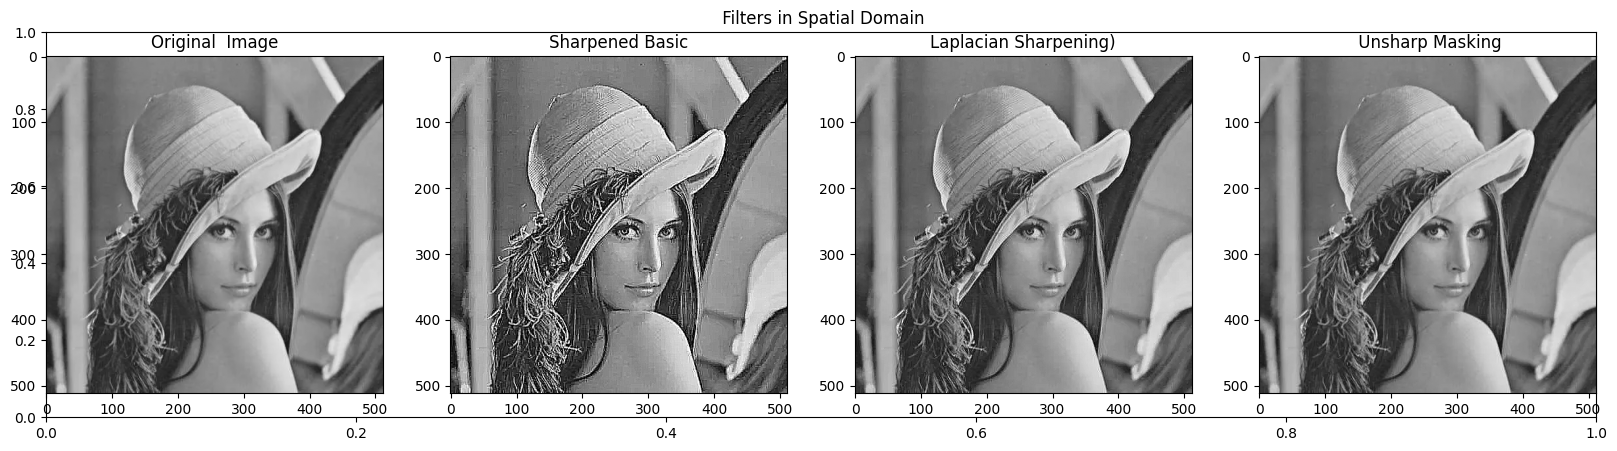

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load the image
image = cv2.imread('/content/LADY1.webp',0)

# 1. Basic Kernel Sharpening
# Define a 3x3 sharpening kernel
kernel = np.array([[-1, -1, -1],
                   [-1,  9, -1],
                   [-1, -1, -1]])
sharpened_basic = cv2.filter2D(image, -1, kernel)

# 2. Laplacian Sharpening
# The Laplacian highlights edges; adding it back to the original sharpens it
laplacian = cv2.Laplacian(image, cv2.CV_64F)
# Convert back to uint8 and combine (subtraction/addition depending on kernel sign)
sharpened_laplacian = cv2.convertScaleAbs(image - 0.5 * laplacian)


# 3. Unsharp Masking
# Create a blurred version (low-pass)
gaussian_blur = cv2.GaussianBlur(image, (5, 5), 1.0)
# Formula: original + amount * (original - blurred)
sharpened_unsharp = cv2.addWeighted(image, 1.5, gaussian_blur, -0.5, 0)


plt.figure(figsize=(20, 5))
plt.title(' Filters in Spatial Domain')
plt.subplot(1, 4, 1),
plt.imshow(image,cmap='gray'),
plt.title('Original  Image')
plt.subplot(1, 4, 2), plt.imshow(sharpened_basic,cmap='gray'),
plt.title('Sharpened Basic')
plt.subplot(1, 4, 3), plt.imshow(sharpened_laplacian,cmap='gray'),
plt.title('Laplacian Sharpening)')
plt.subplot(1, 4, 4), plt.imshow(sharpened_unsharp ,cmap='gray'),
plt.title(' Unsharp Masking')
plt.show()


Lowpass filters: Allow passing only low frequency details, attenuates the high frequency details. Example: Smoothening filters.


Highpass filters: Allows passing only high frequency details, attenuates the low frequency details. Example: Sharpening mask filters.

High Pass Filter (HPF): Created by subtracting a lowpass filtered image from the original image (\(Original-LPF\)).

Bandreject filters: Attenuate signal in range of a certain frequency. Allows frequency below a certain threshold and above another threshold to pass.

Band Reject Filter (BRF): Formed by the sum of a lowpass filtered image and a highpass filtered image with different cutoff frequencies (\(LPF_{low\_cutoff}+HPF_{high\_cutoff}\)).


Bandpass filters: Only allows signals within a certain band to pass, attenuates the frequencies below a threshold and above another threshold to pass.  

Band Pass Filter (BPF): Obtained by subtracting a band reject filtered image from the original image (\(Original-BRF\))